# Black-box simulation evaluation

This notebook runs a direct decision / black-box expanding-window evaluation on the simulated macro-financial dataset. The models learn oracle allocation directly and do **not** forecast charge-offs or train PtO/DFL models.

## 1. Imports and setup

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.exceptions import ConvergenceWarning

SEED = 42
np.random.seed(SEED)

if "seaborn-v0_8-whitegrid" in plt.style.available:
    plt.style.use("seaborn-v0_8-whitegrid")
elif "seaborn-whitegrid" in plt.style.available:
    plt.style.use("seaborn-whitegrid")
else:
    plt.style.use("default")

pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


def find_repo_root(start=None):
    """Find the repository root from repo root, models/simulation, or a notebook subfolder."""
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "models" / "src").exists() and (candidate / "models" / "simulation" / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Set REPO_ROOT manually in this cell.")


REPO_ROOT = find_repo_root()
MODELS_SRC = REPO_ROOT / "models" / "src"
if str(MODELS_SRC) not in sys.path:
    sys.path.insert(0, str(MODELS_SRC))

from capital_allocation_utils import CapitalConfig, annualised_pd_from_chargeoff, optimise_oracle_alpha, realised_utility

print(f"Repo root: {REPO_ROOT}")

Repo root: /Users/hannahokeeffe/Documents/Imperial/DFL_New


## 2. Load simulated data

In [2]:
simulation_csv = REPO_ROOT / "models" / "simulation" / "data" / "simulated_variables.csv"
df = pd.read_csv(simulation_csv)

if "time" in df.columns:
    df["DATE"] = pd.to_datetime(df["time"])
elif "DATE" in df.columns:
    df["DATE"] = pd.to_datetime(df["DATE"])
else:
    raise ValueError("The simulated panel must contain either 'time' or 'DATE'.")

df = df.sort_values("DATE").reset_index(drop=True)

# First-class schema from simulated_variables.ipynb. The fallback list keeps older
# generated panels loadable while this notebook is being iterated.
new_feature_cols = ["activity", "labour_market_stress", "financial_conditions"]
legacy_feature_cols = [
    "sim_persistent_stress_indicator",
    "sim_noisy_leading_indicator",
    "sim_noisy_leading_indicator_lag1",
    "sim_irrelevant_noise",
]
if all(col in df.columns for col in new_feature_cols):
    feature_cols = new_feature_cols
else:
    feature_cols = [col for col in legacy_feature_cols if col in df.columns]

if not feature_cols:
    raise ValueError("No recognised synthetic macro feature columns found in the dataset.")

chargeoff_candidates = ["charge_off_rate", "sim_chargeoff", "sim_charge_off_rate", "sim_chargeoff_rate"]
chargeoff_source = next((col for col in chargeoff_candidates if col in df.columns), None)
if chargeoff_source is None:
    raise ValueError(f"Could not find charge-off column. Tried: {chargeoff_candidates}")
df["charge_off_rate"] = pd.to_numeric(df[chargeoff_source], errors="coerce")
df["sim_chargeoff"] = df["charge_off_rate"]

if "stress_regime" in df.columns:
    df["is_stress"] = df["stress_regime"].astype(int)
elif "regime" in df.columns:
    df["is_stress"] = df["regime"].astype(int)
elif "regime_label" in df.columns:
    df["is_stress"] = df["regime_label"].str.lower().eq("stress").astype(int)
else:
    raise ValueError("The simulated panel must contain 'stress_regime', 'regime', or 'regime_label'.")

df["stress_regime"] = df["is_stress"]
df["regime_label"] = np.where(df["is_stress"].eq(1), "stress", "normal")

if "oracle_alpha" in df.columns:
    df["alpha_oracle_input"] = pd.to_numeric(df["oracle_alpha"], errors="coerce")
elif "sim_oracle_alpha" in df.columns:
    df["alpha_oracle_input"] = pd.to_numeric(df["sim_oracle_alpha"], errors="coerce")
else:
    df["alpha_oracle_input"] = np.nan

if "true_stress_probability" not in df.columns and "sim_true_stress_probability" in df.columns:
    df["true_stress_probability"] = df["sim_true_stress_probability"]

if "sim_quarterly_pd" in df.columns and "sim_pd_q" not in df.columns:
    df["sim_pd_q"] = df["sim_quarterly_pd"]
if "sim_annual_pd" in df.columns and "sim_pd_a" not in df.columns:
    df["sim_pd_a"] = df["sim_annual_pd"]

df = df.dropna(subset=feature_cols + ["charge_off_rate", "is_stress"]).reset_index(drop=True)

print(f"Loaded {len(df)} quarterly observations from {simulation_csv.relative_to(REPO_ROOT)}")
print(f"Features: {feature_cols}")
print(f"Charge-off source: {chargeoff_source} -> charge_off_rate")
display_cols = ["DATE", "is_stress", *feature_cols, "true_stress_probability", "charge_off_rate"]
display(df[[col for col in display_cols if col in df.columns]].head())
display(df[["charge_off_rate", "is_stress"]].describe().T)

Loaded 500 quarterly observations from models/simulation/data/simulated_variables.csv
Features: ['activity', 'labour_market_stress', 'financial_conditions']
Charge-off source: charge_off_rate -> charge_off_rate


,DATE,is_stress,activity,labour_market_stress,financial_conditions,true_stress_probability,charge_off_rate
0,2000-01-01,0,-0.233461,1.375665,-0.459927,0.346239,0.012135
1,2000-04-01,0,-0.362790,0.760180,0.490140,0.424864,0.003942
2,2000-07-01,0,0.081477,0.251652,0.518976,0.242494,0.011362
3,2000-10-01,1,-0.255237,1.035646,0.184373,0.403124,0.006165
4,2001-01-01,0,-0.121132,0.972103,0.830311,0.495556,0.007996


,count,mean,std,min,25%,50%,75%,max
charge_off_rate,500.0,0.008284,0.00537,0.000018,0.004679,0.007429,0.010875,0.030154
is_stress,500.0,0.224000,0.41734,0.000000,0.000000,0.000000,0.000000,1.000000


## 3. Define or import decision evaluation functions

The black-box model predicts alpha directly. Realised utility and oracle alpha are evaluated with the same existing capital allocation utilities used elsewhere in the project.

In [3]:
cap_cfg = CapitalConfig(lgd=0.45, leverage=10)


def quarterly_pd_from_chargeoff(chargeoff, cfg=cap_cfg):
    pd_q = np.asarray(chargeoff, dtype=float) / cfg.lgd
    return np.clip(pd_q, cfg.pd_floor, cfg.pd_cap)


def annual_pd_from_chargeoff(chargeoff, cfg=cap_cfg):
    return annualised_pd_from_chargeoff(chargeoff, cfg)


def clip_alpha(alpha):
    return float(np.clip(alpha, 0.0, 1.0))


def oracle_alpha_for_chargeoff(chargeoff, cfg=cap_cfg):
    return optimise_oracle_alpha(float(chargeoff), cfg)


def oracle_alpha_for_row(row, cfg=cap_cfg):
    if pd.notna(row.get("alpha_oracle_input", np.nan)):
        return float(row["alpha_oracle_input"])
    return oracle_alpha_for_chargeoff(float(row["charge_off_rate"]), cfg)


def regret_from_realisation(alpha_model, alpha_oracle, realised_chargeoff, cfg=cap_cfg):
    oracle_utility = realised_utility(float(alpha_oracle), float(realised_chargeoff), cfg)
    model_utility = realised_utility(float(alpha_model), float(realised_chargeoff), cfg)
    return oracle_utility - model_utility, model_utility, oracle_utility


# Train and evaluate against the oracle alpha generated with the synthetic panel.
df["alpha_oracle"] = [oracle_alpha_for_row(row, cap_cfg) for _, row in df.iterrows()]
df["oracle_alpha"] = df["alpha_oracle"]

df["sim_pd_q"] = quarterly_pd_from_chargeoff(df["charge_off_rate"], cap_cfg)
df["sim_pd_a"] = annual_pd_from_chargeoff(df["charge_off_rate"], cap_cfg)

display(df[["DATE", "charge_off_rate", "sim_pd_q", "sim_pd_a", "alpha_oracle"]].head())

,DATE,charge_off_rate,sim_pd_q,sim_pd_a,alpha_oracle
0,2000-01-01,0.012135,0.026966,0.103579,0.457
1,2000-04-01,0.003942,0.008759,0.034580,0.621
2,2000-07-01,0.011362,0.025248,0.097233,0.466
3,2000-10-01,0.006165,0.013701,0.053688,0.558
4,2001-01-01,0.007996,0.017769,0.069206,0.519


## 4. Expanding-window evaluation

In [4]:
initial_train_window = int(0.7*len(df))
if len(df) <= initial_train_window:
    initial_train_window = max(40, int(np.floor(0.75 * len(df))))

print(f"Initial training window: {initial_train_window} quarters")
print("Training regime counts:")
display(df.iloc[:initial_train_window]["is_stress"].value_counts().rename(index={0: "normal", 1: "stress"}))
print("Test regime counts:")
display(df.iloc[initial_train_window:]["is_stress"].value_counts().rename(index={0: "normal", 1: "stress"}))


def make_models(seed=SEED):
    return {
        "black_box_linear": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]),
        "black_box_mlp": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(16, 16),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=2000,
                random_state=seed,
                early_stopping=False,
            )),
        ]),
    }


def run_expanding_window(data, feature_cols, initial_window):
    rows = []

    for t in range(initial_window, len(data)):
        train = data.iloc[:t]
        test = data.iloc[[t]]

        x_train = train[feature_cols]
        y_train = train["alpha_oracle"]
        x_test = test[feature_cols]
        actual_chargeoff = float(test["charge_off_rate"].iloc[0])
        alpha_oracle = float(test["alpha_oracle"].iloc[0])

        for model_name, model in make_models(seed=SEED + t).items():
            model.fit(x_train, y_train)
            alpha_raw = float(model.predict(x_test)[0])
            alpha_pred = clip_alpha(alpha_raw)
            regret, model_utility, oracle_utility = regret_from_realisation(
                alpha_pred,
                alpha_oracle,
                actual_chargeoff,
                cap_cfg,
            )

            rows.append({
                "DATE": test["DATE"].iloc[0],
                "model": model_name,
                "train_size": t,
                "is_stress": int(test["is_stress"].iloc[0]),
                "regime_label": "stress" if int(test["is_stress"].iloc[0]) == 1 else "normal",
                "actual_chargeoff": actual_chargeoff,
                "actual_pd_q": float(test["sim_pd_q"].iloc[0]) if "sim_pd_q" in test.columns else np.nan,
                "actual_pd_a": float(test["sim_pd_a"].iloc[0]) if "sim_pd_a" in test.columns else np.nan,
                "alpha_oracle": alpha_oracle,
                "alpha_pred_raw": alpha_raw,
                "alpha_pred": alpha_pred,
                "alpha_error": alpha_pred - alpha_oracle,
                "realised_utility": model_utility,
                "oracle_utility": oracle_utility,
                "regret": regret,
            })

    results = pd.DataFrame(rows)
    results["cumulative_regret"] = results.groupby("model")["regret"].cumsum()
    return results


results = run_expanding_window(df, feature_cols, initial_train_window)
display(results.head())
display(results.groupby("model")["DATE"].count().rename("n_test_quarters"))

Initial training window: 350 quarters
Training regime counts:


normal    259
stress     91
Name: is_stress, dtype: int64

Test regime counts:


normal    129
stress     21
Name: is_stress, dtype: int64

,DATE,model,train_size,is_stress,regime_label,actual_chargeoff,actual_pd_q,actual_pd_a,alpha_oracle,alpha_pred_raw,alpha_pred,alpha_error,realised_utility,oracle_utility,regret,cumulative_regret
0,2087-07-01,black_box_linear,350,0,normal,0.008480,0.018844,0.073271,0.510,0.545104,0.545104,0.035104,0.547866,1.211754,0.663887,0.663887
1,2087-07-01,black_box_mlp,350,0,normal,0.008480,0.018844,0.073271,0.510,0.589666,0.589666,0.079666,-0.306603,1.211754,1.518357,1.518357
2,2087-10-01,black_box_linear,351,0,normal,0.007991,0.017758,0.069161,0.519,0.551368,0.551368,0.032368,0.618915,1.218027,0.599112,1.262999
3,2087-10-01,black_box_mlp,351,0,normal,0.007991,0.017758,0.069161,0.519,0.384309,0.384309,-0.134691,1.161444,1.218027,0.056582,1.574939
4,2088-01-01,black_box_linear,352,0,normal,0.001505,0.003345,0.013314,0.752,0.562823,0.562823,-0.189177,1.272939,1.364679,0.091741,1.354740


model
black_box_linear    150
black_box_mlp       150
Name: n_test_quarters, dtype: int64

## 5. Metrics

In [5]:
def summarise_model(group):
    return pd.Series({
        "alpha_prediction_mse": mean_squared_error(group["alpha_oracle"], group["alpha_pred"]),
        "alpha_prediction_mae": mean_absolute_error(group["alpha_oracle"], group["alpha_pred"]),
        "mean_regret": group["regret"].mean(),
        "median_regret": group["regret"].median(),
        "regret_p95": group["regret"].quantile(0.95),
        "mean_regret_normal": group.loc[group["is_stress"].eq(0), "regret"].mean(),
        "mean_regret_stress": group.loc[group["is_stress"].eq(1), "regret"].mean(),
        "cumulative_regret": group["regret"].sum(),
    })


metrics = results.groupby("model").apply(summarise_model)
display(metrics)

,alpha_prediction_mse,alpha_prediction_mae,mean_regret,median_regret,regret_p95,mean_regret_normal,mean_regret_stress,cumulative_regret
model,,,,,,,,
black_box_linear,0.016918,0.090728,1.045576,0.600195,3.722614,0.778154,2.688312,156.836410
black_box_mlp,0.020635,0.104765,1.042889,0.242785,4.015378,0.863907,2.142351,156.433353


## 6. Plots

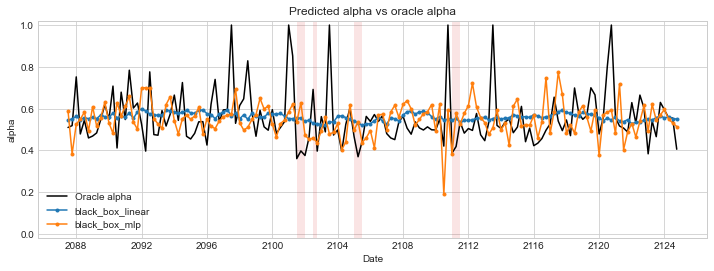

In [6]:
def shade_stress_periods(ax, dates, is_stress, color="tab:red", alpha=0.12):
    dates = pd.Series(pd.to_datetime(dates)).reset_index(drop=True)
    is_stress = pd.Series(is_stress).reset_index(drop=True).astype(bool)
    in_stress = False
    start = None
    for i, stress_now in enumerate(is_stress):
        if stress_now and not in_stress:
            start = dates.iloc[i]
            in_stress = True
        if in_stress and ((not stress_now) or i == len(is_stress) - 1):
            end = dates.iloc[i] if stress_now else dates.iloc[max(i - 1, 0)]
            ax.axvspan(start, end, color=color, alpha=alpha, linewidth=0)
            in_stress = False


test_regimes = df.loc[df["DATE"].isin(results["DATE"].unique()), ["DATE", "is_stress"]]
actual = results.drop_duplicates("DATE")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(actual["DATE"], actual["alpha_oracle"], color="black", label="Oracle alpha")
for model_name, group in results.groupby("model"):
    ax.plot(group["DATE"], group["alpha_pred"], marker="o", markersize=3, label=model_name)
shade_stress_periods(ax, test_regimes["DATE"], test_regimes["is_stress"])
ax.set_title("Predicted alpha vs oracle alpha")
ax.set_ylabel("alpha")
ax.set_xlabel("Date")
ax.set_ylim(-0.02, 1.02)
ax.legend()
plt.show()

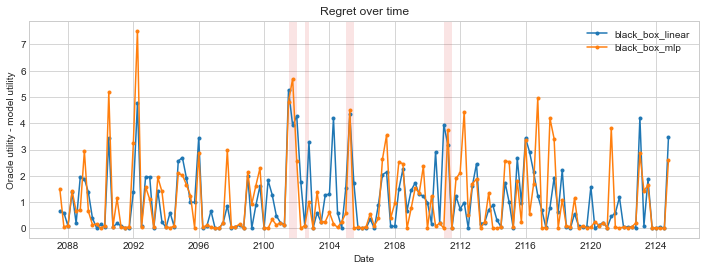

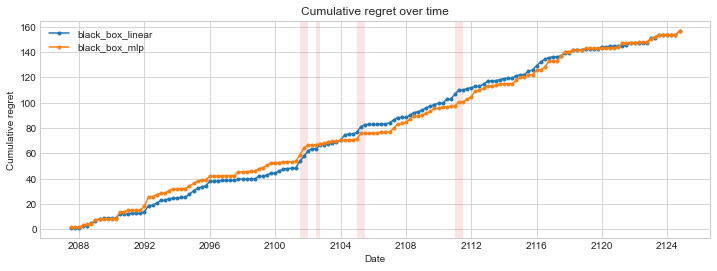

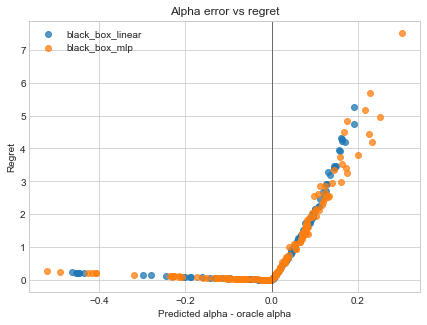

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
for model_name, group in results.groupby("model"):
    ax.plot(group["DATE"], group["regret"], marker="o", markersize=3, label=model_name)
shade_stress_periods(ax, test_regimes["DATE"], test_regimes["is_stress"])
ax.set_title("Regret over time")
ax.set_ylabel("Oracle utility - model utility")
ax.set_xlabel("Date")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for model_name, group in results.groupby("model"):
    ax.plot(group["DATE"], group["cumulative_regret"], marker="o", markersize=3, label=model_name)
shade_stress_periods(ax, test_regimes["DATE"], test_regimes["is_stress"])
ax.set_title("Cumulative regret over time")
ax.set_ylabel("Cumulative regret")
ax.set_xlabel("Date")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for model_name, group in results.groupby("model"):
    ax.scatter(group["alpha_error"], group["regret"], alpha=0.75, label=model_name)
ax.axvline(0.0, color="black", linewidth=1, alpha=0.5)
ax.set_title("Alpha error vs regret")
ax.set_xlabel("Predicted alpha - oracle alpha")
ax.set_ylabel("Regret")
ax.legend()
plt.show()

## 7. Save results

In [8]:
results_dir = REPO_ROOT / "models" / "simulation" / "results"
results_dir.mkdir(parents=True, exist_ok=True)

results_csv = results_dir / "black_box_simulation_results.csv"
results.to_csv(results_csv, index=False)

print(f"Saved black-box simulation results to: {results_csv.relative_to(REPO_ROOT)}")
display(results.head())

Saved black-box simulation results to: models/simulation/results/black_box_simulation_results.csv


,DATE,model,train_size,is_stress,regime_label,actual_chargeoff,actual_pd_q,actual_pd_a,alpha_oracle,alpha_pred_raw,alpha_pred,alpha_error,realised_utility,oracle_utility,regret,cumulative_regret
0,2087-07-01,black_box_linear,350,0,normal,0.008480,0.018844,0.073271,0.510,0.545104,0.545104,0.035104,0.547866,1.211754,0.663887,0.663887
1,2087-07-01,black_box_mlp,350,0,normal,0.008480,0.018844,0.073271,0.510,0.589666,0.589666,0.079666,-0.306603,1.211754,1.518357,1.518357
2,2087-10-01,black_box_linear,351,0,normal,0.007991,0.017758,0.069161,0.519,0.551368,0.551368,0.032368,0.618915,1.218027,0.599112,1.262999
3,2087-10-01,black_box_mlp,351,0,normal,0.007991,0.017758,0.069161,0.519,0.384309,0.384309,-0.134691,1.161444,1.218027,0.056582,1.574939
4,2088-01-01,black_box_linear,352,0,normal,0.001505,0.003345,0.013314,0.752,0.562823,0.562823,-0.189177,1.272939,1.364679,0.091741,1.354740
